# <b>Producing Images with a Generative Adversarial Network</b>

### <b>1 | Import Libraries</b>

In [9]:
# core modules
from random import random, randint
from copy import deepcopy

# neural network
import torch
import torch.nn as nn
import torch.optim as optim

# maths and data handling
import numpy as np
import pandas as pd

# visualisation
import matplotlib.pyplot as plt

### <b>2 | Load and Process Data</b>

In [10]:
# load compressed image files
images = np.loadtxt(
    fname='data/birbAI_processed_image_array.gz',
    delimiter=','
)

ROW INDEX: 5966


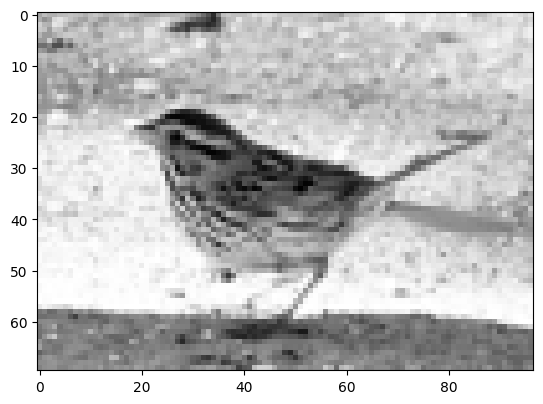

In [11]:
# pick a random image
selection = randint(1,len(images))
print('ROW INDEX:',selection)

# copy and resize the image
pi = deepcopy(images[selection])
pi.resize((70,97))

# show image
plt.imshow(pi, 'Greys_r')

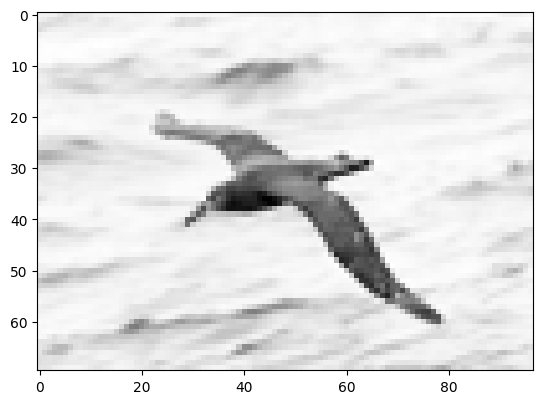

In [12]:
# scale greyscale intensity values for each pixel from 0-255 to 0-1
images_scaled = images/255

# reshape from linear tensor to correct shape
img = np.reshape(images_scaled, (9414,1,70,97))

# plot first image to check formatting
plt.imshow(img[0][0], cmap='Greys_r')

### <b>3 | GAN Model Architecture</b>

In [13]:
class Generator(nn.Module):

    # define generator architecture
    def __init__(self, noise_dim):
        super(Generator, self).__init__()

        self.main = nn.Sequential(
            # Convert noise into correct format for ConvTranspose2d layers
            nn.Linear(noise_dim, 512 * 4 * 6),
            nn.ReLU(True),
            nn.Unflatten(1, (512, 4, 6)),

            # First ConvTranspose Layer: Input (512, 4, 6) -> Output (256, 8, 12)
            nn.ConvTranspose2d(512, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(True),

            # First ConvTranspose Layer: Input (256, 8, 12) -> Output (128, 16, 24)
            nn.ConvTranspose2d(256, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(True),
            
            # First ConvTranspose Layer: Input (128, 16, 24) -> Output (1, )
            nn.ConvTranspose2d(128, 1, kernel_size=3, padding=1),
            nn.Sigmoid()
        )

    # create an instance of the generator model
    def forward(self, x):
        return self.main(x)
    


class Discriminator(nn.Module):

    # define discriminator architecture
    def __init__(self):
        super(Discriminator, self).__init__()
        self.main = nn.Sequential(
            # First Conv Layer: Input (1, 70, 97) -> Output (64, 35, 49)
            nn.Conv2d(1, 64, 5, stride=2, padding=2),
            nn.LeakyReLU(0.2, inplace=True),
            nn.BatchNorm2d(64),
            
            # Second Conv Layer: Input (64, 35, 49) -> Output (128, 17, 24)
            nn.Conv2d(64, 128, 5, stride=2, padding=2),
            nn.LeakyReLU(0.2, inplace=True),
            nn.BatchNorm2d(128),
            
            # Third Conv Layer: Input (128, 17, 24) -> Output (256, 8, 12)
            nn.Conv2d(128, 256, 5, stride=2, padding=2),
            nn.LeakyReLU(0.2, inplace=True),
            nn.BatchNorm2d(256),
            
            # Fourth Conv Layer: Input (256, 8, 12) -> Output (512, 4, 6)
            nn.Conv2d(256, 512, 5, stride=2, padding=2),
            nn.LeakyReLU(0.2, inplace=True),
            nn.BatchNorm2d(512),
            
            # Flatten and then linear layer
            nn.Flatten(),
            nn.Linear(512 * 5 * 7, 1)  # (512 * 4 * 6 = 12288)
        )

    def forward(self, x):
        return self.main(x)

### <b>4 | GAN Model Training Loop</b>

In [14]:
# user-defined variables
NOISE_DIM = 128

##############################################
#---------------DEFINE DEVICE----------------#
##############################################

# if GPU is to be used
device = torch.device(
    "cuda" if torch.cuda.is_available() else
    "mps" if torch.backends.mps.is_available() else
    "cpu"
)


##############################################
#---------------DEFINE MODELS------=---------#
##############################################

# create model instances
generator = Generator(NOISE_DIM)
discriminator = Discriminator()

# move models to device
generator = generator.to(device)
discriminator = discriminator.to(device)



##############################################
#-------------DEFINE OPTIMIZERS--------------#
##############################################

# loss criterion
criterion = nn.BCEWithLogitsLoss()

# define model optimizers
generator_optimizer = optim.Adam(
    generator.parameters(), lr=0.0002, betas=(0.5, 0.999))

discriminator_optimizer = optim.Adam(
    discriminator.parameters(), lr=0.0002, betas=(0.5, 0.999))

In [15]:
# user-defined variables
BATCH_SIZE = 256
NUM_EPOCHS = 10

# preparae dataset for model training
train_loader = torch.utils.data.DataLoader(
    img, batch_size=BATCH_SIZE, shuffle=True)

In [ ]:
# set up master lists to hold loss data
list_dis_loss, list_gen_loss = list(), list()

# for each epoch
for epoch in range(NUM_EPOCHS):
    # for each batch
    for i, data in enumerate(train_loader):
        
        # check data type and move to device
        real_images = data.float()
        real_images = real_images.to(device)

        # update discriminator
        discriminator_optimizer.zero_grad()

        # real images
        real_labels = torch.ones(real_images.size(0), 1, device=device)
        real_outputs = discriminator(real_images)
        dis_loss_real = criterion(real_outputs, real_labels)

        # fake images
        noise = torch.randn(real_images.size(0), NOISE_DIM, device=device)
        fake_images = generator(noise)
        fake_labels = torch.zeros(fake_images.size(0), 1, device=device)
        fake_outputs = discriminator(fake_images.detach()) ### detach from gradient for generator
        dis_loss_fake = criterion(fake_outputs, fake_labels)

        # total discriminator loss
        dis_loss = dis_loss_real + dis_loss_fake
        dis_loss.backward()
        discriminator_optimizer.step()

        # update generator
        generator_optimizer.zero_grad()
        gen_fake_labels = torch.ones(real_images.size(0), 1, device=device) ### torch.ones used as this is the desired result we're aiming to get from the discriminator
        gen_fake_outputs = discriminator(fake_images)
        gen_loss = criterion(gen_fake_outputs, gen_fake_labels)
        gen_loss.backward()
        generator_optimizer.step()

        # print progress update
        if i % 10 == 0:
            print(f'Epoch [{epoch+1}/{NUM_EPOCHS}], Step [{i+1}/{len(train_loader)}], '
                  f'Discriminator Loss: {dis_loss.item():.4f}, '
                  f'Generator Loss: {gen_loss.item():.4f}')
            
    # append loss values to master lists
    list_dis_loss.append(dis_loss.item())
    list_gen_loss.append(gen_loss.item())

    # print final note of loss in both models
    print(f'Epoch {epoch+1} ---END---  '
            f'Discriminator Loss: {dis_loss.item():.4f}, '
            f'Generator Loss: {gen_loss.item():.4f}')
    print("------------------------------------------------------------------------------------------------------")

RuntimeError: mat1 and mat2 shapes cannot be multiplied (256x512 and 17920x1)

In [ ]:
# save generator and discriminator model states
torch.save(generator.state_dict(),'data\\birbAI_2 GAN_v1_generator_temporary.pt')
torch.save(discriminator.state_dict(),'data\\birbAI_2 GAN_v1_discriminator_temporary.pt')

<bound method Figure.tight_layout of <Figure size 640x480 with 1 Axes>>

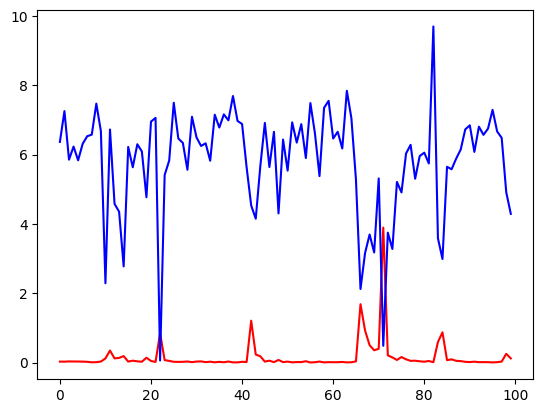

In [ ]:
# create x values for graph (list of integers from 0 of same length as number of epochs)
x = range(0,NUM_EPOCHS,1)

# visualise loss from generator (blue) and discriminator (red) by epoch
fig, ax = plt.subplots(1,1)

ax.plot(x, list_gen_loss, c='blue')
ax.plot(x, list_dis_loss, c='red')

ax.set_xlabel('Number of Epochs')
ax.set_ylabel('Loss (BCEwithLogits)')

fig.tight_layout

### <b>5 | Visualise Real and Generated Images</b>

(np.float64(-0.5), np.float64(96.5), np.float64(69.5), np.float64(-0.5))

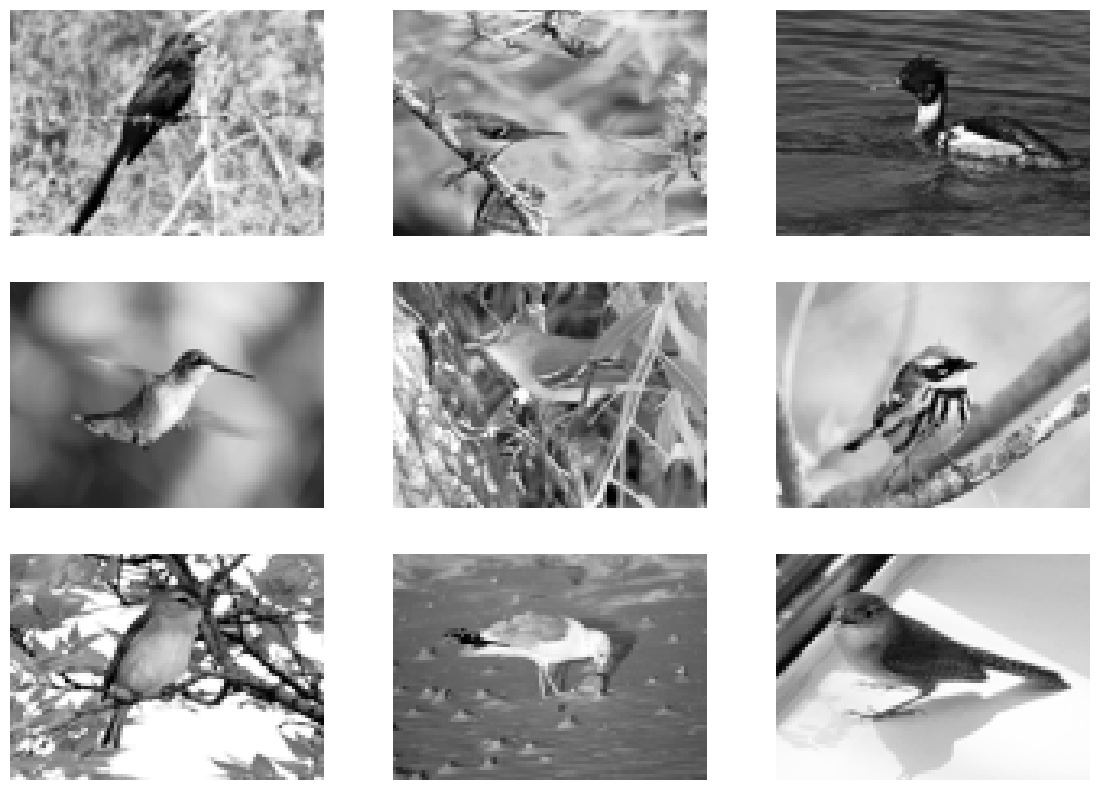

In [ ]:
# display a 3x3 grid of random images from the dataset
fig, ax = plt.subplots(3,3, figsize=(14,10))

ax[0,0].imshow(img[randint(0,9414)][0], cmap='Greys_r')
ax[0,1].imshow(img[randint(0,9414)][0], cmap='Greys_r')
ax[0,2].imshow(img[randint(0,9414)][0], cmap='Greys_r')
ax[1,0].imshow(img[randint(0,9414)][0], cmap='Greys_r')
ax[1,1].imshow(img[randint(0,9414)][0], cmap='Greys_r')
ax[1,2].imshow(img[randint(0,9414)][0], cmap='Greys_r')
ax[2,0].imshow(img[randint(0,9414)][0], cmap='Greys_r')
ax[2,1].imshow(img[randint(0,9414)][0], cmap='Greys_r')
ax[2,2].imshow(img[randint(0,9414)][0], cmap='Greys_r')

ax[0,0].axis('off')
ax[0,1].axis('off')
ax[0,2].axis('off')
ax[1,0].axis('off')
ax[1,1].axis('off')
ax[1,2].axis('off')
ax[2,0].axis('off')
ax[2,1].axis('off')
ax[2,2].axis('off')

<bound method Figure.tight_layout of <Figure size 1400x1000 with 9 Axes>>

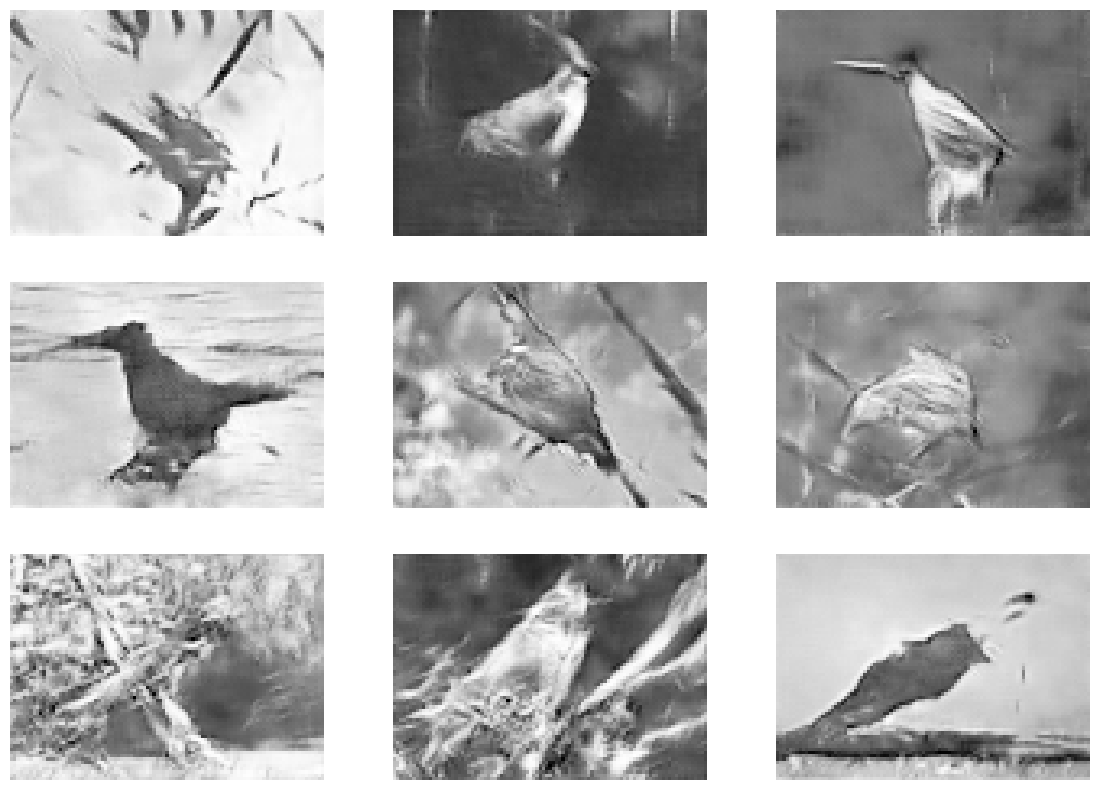

In [ ]:
# generate a tensor of random noise
test_noise = torch.randn(9, NOISE_DIM, device=device)

# use pre-trained generator to create an image
generator.eval()
with torch.no_grad():
    fake_images = generator(test_noise).cpu()


# display a 3x3 grid of generated bird images
fig, ax = plt.subplots(3,3, figsize=(14,10))

ax[0,0].imshow(fake_images[0][0], cmap='Greys_r')
ax[0,1].imshow(fake_images[1][0], cmap='Greys_r')
ax[0,2].imshow(fake_images[2][0], cmap='Greys_r')
ax[1,0].imshow(fake_images[3][0], cmap='Greys_r')
ax[1,1].imshow(fake_images[4][0], cmap='Greys_r')
ax[1,2].imshow(fake_images[5][0], cmap='Greys_r')
ax[2,0].imshow(fake_images[6][0], cmap='Greys_r')
ax[2,1].imshow(fake_images[7][0], cmap='Greys_r')
ax[2,2].imshow(fake_images[8][0], cmap='Greys_r')

ax[0,0].axis('off')
ax[0,1].axis('off')
ax[0,2].axis('off')
ax[1,0].axis('off')
ax[1,1].axis('off')
ax[1,2].axis('off')
ax[2,0].axis('off')
ax[2,1].axis('off')
ax[2,2].axis('off')

fig.tight_layout

(np.float64(-0.5), np.float64(96.5), np.float64(69.5), np.float64(-0.5))

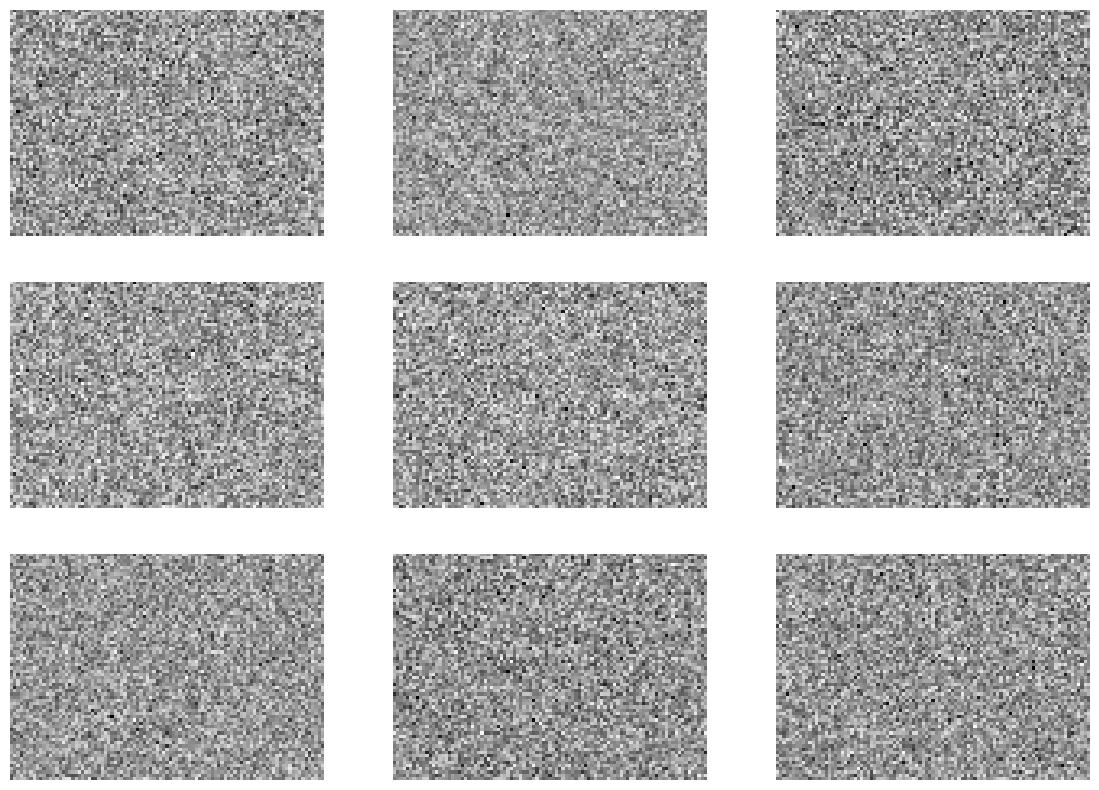

In [ ]:
# generate tensors of random numbers 
rand_noise = torch.randn(9, 70*97, device='cpu')
rand_noise = rand_noise.reshape(9,70,97)


# display a 3x3 grid of random noise tensors
fig, ax = plt.subplots(3,3, figsize=(14,10))

ax[0,0].imshow(rand_noise[0], cmap='Greys_r')
ax[0,1].imshow(rand_noise[1], cmap='Greys_r')
ax[0,2].imshow(rand_noise[2], cmap='Greys_r')
ax[1,0].imshow(rand_noise[3], cmap='Greys_r')
ax[1,1].imshow(rand_noise[4], cmap='Greys_r')
ax[1,2].imshow(rand_noise[5], cmap='Greys_r')
ax[2,0].imshow(rand_noise[6], cmap='Greys_r')
ax[2,1].imshow(rand_noise[7], cmap='Greys_r')
ax[2,2].imshow(rand_noise[8], cmap='Greys_r')

ax[0,0].axis('off')
ax[0,1].axis('off')
ax[0,2].axis('off')
ax[1,0].axis('off')
ax[1,1].axis('off')
ax[1,2].axis('off')
ax[2,0].axis('off')
ax[2,1].axis('off')
ax[2,2].axis('off')

tensor([[-0.1574,  0.0921,  0.6010,  0.1827, -0.5476, -0.7012, -0.3288,  0.1458,
         -0.4289,  0.3585, -0.7965,  1.1869, -0.1073,  0.1923,  1.1930, -0.0348,
         -0.9834, -0.5078, -0.9812, -0.7494, -2.0688,  0.0272,  1.7469,  1.9576,
         -1.7759,  0.1510,  1.4849, -0.2461,  0.4090,  0.4283,  0.4017,  1.0182,
         -1.5120, -0.1964,  0.6543,  0.1050, -1.2488, -2.0528, -0.9128, -0.6349,
         -1.5639,  0.4172,  1.9470, -0.6795, -0.4344, -0.6349,  0.6454, -0.1579,
          0.3591,  0.7235, -0.8914, -0.5953, -1.0919, -0.4389, -0.5206, -0.6310,
         -1.5156,  0.9737, -0.9992,  0.6395,  1.9960, -0.7036, -0.5456, -0.6301,
         -2.8183,  2.9641,  0.8320,  0.4781,  0.4044, -1.5861, -0.8050, -0.1297,
         -1.8473,  0.1757,  0.5275, -3.4734,  0.8214, -1.7863, -0.4921, -0.8519,
          0.1484, -0.4859,  0.5115, -0.2047, -0.7956, -0.8321, -0.3330, -0.8183,
          0.3848, -0.7675, -1.3380,  1.0763, -0.3228,  1.2759, -0.9030, -0.6134,
         -0.9245, -1.1464, -

<bound method Figure.tight_layout of <Figure size 1400x1000 with 9 Axes>>

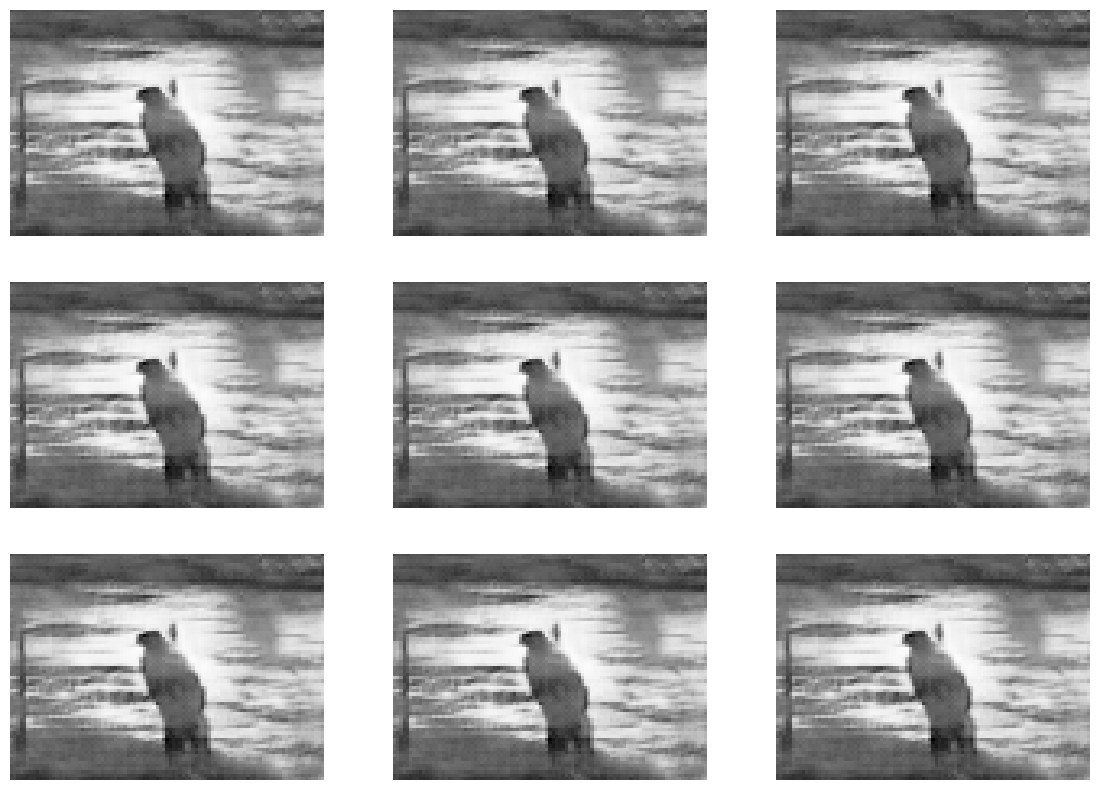

In [ ]:
# generate a noise tensor
test_noise = torch.randn(1, NOISE_DIM, device=device)
print(test_noise)

# use pre-trained generator to create an image
generator.eval()
repeat_generation = list()

for _ in range(0,9,1):   ### feed identical noise to the generator each time and collect the results in a list
    with torch.no_grad():
        repeat_generation.append(generator(test_noise).cpu())


# display a 3x3 grid of images generated from the same noise tensor
fig, ax = plt.subplots(3,3, figsize=(14,10))

ax[0,0].imshow(repeat_generation[0][0][0], cmap='Greys_r')
ax[0,1].imshow(repeat_generation[1][0][0], cmap='Greys_r')
ax[0,2].imshow(repeat_generation[2][0][0], cmap='Greys_r')
ax[1,0].imshow(repeat_generation[3][0][0], cmap='Greys_r')
ax[1,1].imshow(repeat_generation[4][0][0], cmap='Greys_r')
ax[1,2].imshow(repeat_generation[5][0][0], cmap='Greys_r')
ax[2,0].imshow(repeat_generation[6][0][0], cmap='Greys_r')
ax[2,1].imshow(repeat_generation[7][0][0], cmap='Greys_r')
ax[2,2].imshow(repeat_generation[8][0][0], cmap='Greys_r')

ax[0,0].axis('off')
ax[0,1].axis('off')
ax[0,2].axis('off')
ax[1,0].axis('off')
ax[1,1].axis('off')
ax[1,2].axis('off')
ax[2,0].axis('off')
ax[2,1].axis('off')
ax[2,2].axis('off')

fig.tight_layout

In [ ]:
# List of noise giving certain results
    # blackbird_noise, duck#_noise (1-3), songbird#_noise (1-5), crow_noise, diver_noise, wren_noise, nesting_noise, grass_noise,  
    # birdofparadise_noise, cardinal#_noise (1-2), branch#_noise (1-2), puffin_noise, woodpecker_noise, capercaille_noise, raptor_noise

### NOTE: Regenerating exactly the same images from a new start will require the saved model to be uploaded and used

blackbird_noise = torch.tensor(
    [[ 1.0167, -0.2386, -1.1489,  1.0902, -0.1608,  0.2382, -1.0153,  0.8148, -2.2890, -1.0240, -1.9636,  0.2102,  1.4518, -0.3896, -0.1903, -0.0464, -0.8231, -0.5872, -1.6637, -0.3843, -1.5354, -0.5394,  0.5357,  1.6269, -0.4888,  0.4560, -0.9578,  0.5508, -2.4824,  1.0368,  1.1951,  0.0778, 1.1999,  1.6685, -0.5324, -0.7609, -1.7851, -1.7202,  0.4978,  0.2522, 0.5762,  0.6374,  0.3793,  0.4951, -0.3232, -1.6692, -0.0522, -0.2843, -0.0784, -1.2893,  0.0039, -0.4068,  1.0640, -1.1345,  0.3271, -0.3378, -0.3053, -0.0777, -1.3726,  0.4163,  0.8286,  0.4897,  1.1097, -0.1197, -0.1869,  0.0298,  0.0040, -1.0686,  0.5227,  0.2311,  1.0954,  0.1870, -0.4108,  0.5318, -1.2396,  1.4364, -0.2909, -0.8084, -1.1327,  0.3734, 0.7226,  0.6235, -0.3108,  0.3455, -1.3784, -1.2447,  0.5669,  0.0061, -1.7179, -0.2336, -0.2193, -2.0889,  0.6370,  3.5894, -0.5025, -1.3391, 1.2772,  0.4913, -0.6393,  1.5757,  0.4470, -1.2330,  0.3511, -1.3532, 0.7012,  0.5507, -0.1343, -1.7237,  0.2735,  0.6442, -0.1135,  0.6052, -1.2934, -0.8260, -0.6062, -1.1854,  0.8746, -1.1055, -1.0316, -0.6416, 0.3470,  0.3982,  0.1639,  0.1926,  1.2505, -1.3065,  0.0369, -1.5749]], 
    device=device
)

duck1_noise = torch.tensor(
    [[-1.9820, -0.7522,  0.3381, -0.1650,  1.8934, -1.0987, -0.1451,  2.1320, 1.6112, -0.0471,  0.4375, -0.1186, -1.0316,  0.6719, -0.9579, -1.0777, -1.1377, -2.1203, -1.2361,  2.0891,  0.5701, -0.1550,  0.2240,  0.5520, 0.1521,  1.3734,  0.3729,  1.7508, -0.9365,  0.1753, -0.2576,  0.7959, -0.2338,  0.0983, -0.7793, -0.4635,  0.0126, -0.1608, -0.7782, -0.4371, 0.1990,  0.6934, -1.2986, -0.6168, -1.7832,  1.0937, -0.1804, -0.4569, 0.4650, -0.0936, -1.6551, -0.4767, -1.7708, -0.7695,  0.7838, -0.2589, 1.5026, -0.0140,  1.0821, -1.0738, -1.5962, -0.3970, -0.1725,  0.3198, 0.8714, -0.1863,  0.6799,  1.2711, -0.2105, -0.8733,  1.2466,  1.6886, 0.3916, -1.0927, -1.8170,  0.3701, -1.3826,  0.4182, -0.1935, -0.2163, -1.0419, -0.3705, -1.2611,  1.0239,  0.8776, -0.9345, -1.0250,  0.3511, 0.9926,  0.4140,  0.2787,  0.5342,  1.4887, -0.2563, -0.8328,  1.7884, 2.3743,  0.9057, -0.9153,  0.2402,  2.6025,  0.3680, -0.1383, -1.4711, 0.7292,  0.5578, -1.0156, -0.7097,  0.1072, -0.8303,  0.0558,  0.0397, -0.8204,  2.3441, -0.1583, -0.1988, -1.4397, -0.0778,  0.6980, -0.7141, -1.7507,  1.1262, -0.1116,  1.8869,  1.5046, -0.9448, -0.4782, -0.9490]],
    device=device
)

songbird1_noise = torch.tensor(
    [[-3.9345e-01, -1.9624e+00,  5.8590e-01,  5.8542e-01, -1.6118e-01, -1.0711e+00,  1.9402e+00,  1.5027e-01,  2.9193e-01, -1.4882e+00, -6.2469e-01,  4.6114e-01,  2.1447e+00, -3.1481e-01,  1.4371e+00, -6.4862e-01, -2.0386e-01,  2.8957e+00,  2.9593e+00, -7.3612e-01, -5.8227e-01,  3.9103e-01,  1.0963e+00,  8.6786e-01,  1.3362e-01, 2.0350e+00,  9.8303e-01, -1.2993e-02, -3.0618e-01,  6.6205e-01, -7.1836e-01, -7.9691e-01, -1.3205e+00,  1.5373e+00, -1.4098e+00, -6.4889e-02,  1.0413e+00,  5.0608e-01,  5.7500e-01, -8.7617e-01, -5.8689e-01,  1.1698e+00,  1.0029e+00,  1.1154e+00, -7.5922e-02, -1.1340e+00, -2.3004e-01,  1.3200e+00,  6.5807e-02, -8.4834e-01, 2.2482e+00, -1.0597e+00, -6.7922e-01, -1.6744e+00,  1.2359e+00, -7.6385e-01,  8.5576e-01, -2.9768e-01,  2.1665e-01, -6.2148e-01, 2.3987e-01,  4.7377e-02,  7.9054e-01,  1.6848e-03, -6.2601e-01, -8.3327e-01,  7.7468e-01,  6.9275e-02,  5.9845e-01, -3.3195e-01, 5.8208e-01, -1.9976e-01,  3.3945e-01,  3.2169e-01, -1.6650e+00, 8.6027e-01,  2.0131e-01,  1.6665e+00,  9.0224e-01, -6.0420e-01, -1.6467e-03, -1.6482e+00, -4.5830e-01,  2.3599e-01,  1.7289e+00, 1.0353e+00,  1.4232e+00, -2.1540e+00, -9.5000e-02, -3.8201e-01, 1.4796e-01, -4.4820e-02, -2.5139e+00,  6.5035e-01,  6.0538e-01, 7.5392e-01,  9.3261e-01,  2.7363e+00, -4.5169e-01, -1.6853e+00, 1.2470e+00, -1.0852e+00, -1.2471e+00,  2.0473e+00, -1.3375e+00, 4.3603e-02, -1.4634e+00,  1.6290e+00,  1.5406e+00, -6.2240e-01, -9.5853e-01,  1.7233e+00,  5.1445e-01,  2.5113e+00,  6.7565e-01, -7.3491e-01, -5.6222e-01,  9.3545e-01,  1.1315e+00, -6.8660e-01, 1.6430e+00,  1.0502e+00,  1.2402e+00,  3.9332e-01,  2.7013e-01, -6.6816e-02, -5.2645e-01,  5.4822e-01]],
    device=device
)

crow_noise = torch.tensor(
    [[ 0.8179,  0.0221, -1.0383,  0.6247,  2.0396, -0.1621, -0.8046,  0.3680, -1.0110,  0.2730,  0.6687, -0.1485,  0.9533, -0.1700,  1.1793, -0.3670, -0.8152,  1.0918,  0.5614, -1.5537,  0.0335, -0.5125, -0.3342,  0.9130, 0.5521,  0.3559,  0.1425, -1.6998,  0.1253,  0.0307,  0.0560, -0.2467, -0.9773, -0.9846,  0.1584,  0.3948,  0.0166, -0.2717, -0.3415,  0.6166, -0.1229,  1.6547, -0.8061,  0.1613,  0.3394,  0.0311, -0.6950, -0.5350, -0.3169,  0.2995,  1.6345,  0.4287,  1.2381, -1.1425,  0.0256, -0.0831, -0.4338, -1.8276, -0.3427, -0.7595,  0.5265, -0.0558, -0.6337,  0.9102, 0.3117,  0.5072, -0.3055, -2.1783, -0.1502,  2.2093,  0.2384, -0.4592, 0.3304, -0.1823, -1.0066, -0.1280, -0.7440,  0.6757,  0.1451, -1.2356, 0.1340,  2.0091, -0.4904, -0.2571,  0.6981, -1.6063,  0.7036,  1.0265, -1.2884, -1.2280,  0.2119, -1.2099,  0.7674,  0.0622,  0.5592,  0.5948, 2.0768,  0.4541, -0.6519,  0.3216,  1.9725, -0.0114,  0.9633, -2.0215, 0.5033, -0.8314, -1.1176, -0.2149,  0.6441, -1.7975, -0.4338,  0.1508, -2.0314,  1.0693,  1.6021,  0.7034, -0.2448,  1.2018, -0.3797, -0.5195, 0.3348,  0.2793,  1.0444, -0.2739, -3.0189, -0.3812, -2.5042, -0.2466]],
    device=device
)

diver_noise = torch.tensor(
    [[ 1.6931,  0.9923, -0.2972, -0.2413,  0.5064, -1.4614, -0.4113,  2.1248, -0.6278, -0.8377, -1.0650,  0.5094, -0.3891,  0.4917, -1.7591,  0.7479, -0.1811, -1.3238,  1.1775, -2.4034,  0.0449,  0.4406, -0.1233, -0.3836, 1.0300, -0.6235,  0.1047, -1.1064,  0.6232,  1.6518,  1.9266, -0.0380, 1.2756,  0.0618, -2.0907,  0.3068,  0.8384,  0.7455, -0.4632, -0.0399, 0.5437, -1.0001,  0.4493, -0.5440, -0.2874,  2.3016,  1.3420, -0.3884, -1.9385, -0.7097, -0.8792, -0.1623, -1.6857,  0.2408, -1.2584,  1.1750, 0.9403,  0.6262, -0.2553, -2.2622, -1.0575,  1.2996, -0.9348,  0.8683, 0.8077, -1.5081,  0.5682,  0.1951,  1.2699,  0.2925,  0.8803, -0.3365, 0.2918,  0.8131, -0.2109, -1.4640,  0.3683, -1.1021, -0.1817, -0.6823, 0.5988,  0.2518,  0.8697,  1.2739,  0.4086,  0.5383,  1.3812, -0.0198, 1.0267, -1.5878, -0.4159,  1.5740, -1.3071, -1.1824,  0.5226,  1.1071, -0.1867, -0.2274,  0.3779, -0.2673, -0.0853, -0.6763, -0.6019, -0.1868, 0.2162,  0.2520, -2.2045, -0.1220,  0.5702, -0.9096,  0.6684,  2.3699, 0.0511,  0.9678,  0.5249, -0.1294,  2.3992, -0.9583, -0.5689, -1.0712, 1.4598,  0.4251,  0.1121, -0.7904, -0.0702, -0.0048,  1.0852, -0.7989]],
    device=device
)

wren_noise = torch.tensor(
    [[-0.5582, -0.5003,  0.4367, -1.0298,  0.5193,  1.8651, -0.0482, -0.4845, -2.0593, -0.3335,  0.5924,  0.5883,  0.0688,  1.4874,  0.6740,  0.8487, -0.6165,  1.0870, -2.1618,  0.4115,  1.1059,  1.1327,  0.2095, -0.1407, 0.3971, -0.0971, -0.3713,  0.9571,  0.0170, -0.8022,  0.6670, -0.6424, 0.4529,  0.1532, -1.9231,  1.1614,  0.7477, -0.1895,  1.6860, -1.3050, -1.5465, -0.9818,  0.8948,  2.5779,  1.2298, -0.4954,  0.5987, -1.5563, -0.9786, -0.6851,  0.4454, -1.7437, -0.8844, -1.2826, -0.0680,  0.7719, 1.5856,  1.8548, -0.9424, -1.0533, -1.2484, -0.2104,  1.2387, -0.3052, 0.9188, -0.9576, -0.1536,  2.4690, -0.2648,  0.1201, -0.3818, -0.3834, 0.0862, -0.7524, -1.6876,  1.5340, -0.3412,  0.1344,  2.2236,  1.4721, 0.5925, -0.7439, -0.6681, -0.9123, -0.3969, -1.3139, -1.8363,  1.1793, -1.5963, -0.1129, -0.1589, -0.0393, -1.4354,  0.9219,  0.8851,  1.0792, 0.1864,  0.7246,  0.0137,  0.2012, -0.4720,  1.0625,  1.0451, -2.6805, -0.1179, -0.5845, -0.2635, -0.4060, -0.3026,  1.2150, -1.7210,  0.4603, -1.1098,  0.2298,  1.5869,  0.3218, -1.5588,  2.0145,  1.1040,  2.4137, 0.9337, -0.2985,  0.9865, -0.1825, -0.4998, -1.2808,  0.6103, -0.0222]],
    device=device
)

nesting_noise = torch.tensor(
    [[ 0.9938,  1.1927, -0.0428, -0.5363, -0.0709,  0.4520, -0.4813, -0.3804, -1.3066,  0.0642, -0.7119, -1.1014, -0.2028, -0.3082,  0.4848,  0.2480, 0.3091, -0.0502,  0.2491,  0.2680,  1.2398,  0.9287,  0.8185,  0.0682, 0.4177,  0.3293, -1.4858,  0.1651,  0.1812, -1.7232, -0.9059, -1.1649, 1.6493, -0.1873,  0.9222, -2.0843,  1.5392,  0.0144, -0.2677, -1.5686, 0.0525,  0.4324, -0.0100,  0.8345, -0.9338,  2.9254,  0.5070, -0.2485, 0.0517,  0.8581, -1.0588,  0.7395,  0.2270, -0.7602, -0.0706,  0.9098, 0.4119, -1.6887, -0.9651,  0.6703,  0.7853, -0.6377,  0.1574,  0.7299, -0.0395,  1.0356,  1.1508,  0.6852,  0.9603, -0.8702,  0.1027,  0.0609, -0.6411, -0.7426,  1.4506, -0.6291,  1.1131, -0.1679,  1.5984,  0.8790, -1.9911, -0.4821,  0.7410, -2.1510, -1.4096, -0.1804, -0.3873, -0.0722, -0.3330,  0.0394,  0.0121,  1.3120,  0.7644,  0.1972, -0.2204, -0.9493, 1.0999,  0.5625, -0.1460, -0.3762, -0.0480,  0.2423,  0.0953, -0.2394, -0.5587,  0.3552,  0.3018, -1.4227,  0.7797,  0.3073, -0.4830, -0.3524, -0.8139, -0.2688,  0.4358, -0.5027,  0.1624,  0.4182,  0.0754, -0.4548, -0.4747,  0.5113,  0.7037,  0.0046, -0.0865, -0.8346,  2.1390,  0.5882]],
    device=device
)

songbird2_noise = torch.tensor(
    [[ 0.6597, -0.4111, -0.5642,  0.8452,  0.2668,  1.0155,  0.1681,  1.3110, -0.0693, -1.0112, -0.9288,  0.4964, -1.0027, -1.1092,  0.4049, -0.0467, -1.2843,  1.6240,  0.5145,  0.5811, -0.4421, -1.1860,  1.5307, -2.5205, -0.7703,  0.0609,  0.2882, -0.0801, -0.0289,  1.0086,  1.5236, -0.2600, -1.8518,  1.0246,  0.3958, -0.2402, -0.8501, -0.1317, -0.4714, -1.2061, 0.1980, -0.3281, -0.6635,  0.4395,  0.3973,  0.5541,  1.2537,  2.2485, 1.3196, -0.5847,  0.4897,  1.5775,  0.2133,  0.5680, -0.2026,  1.2227, 1.9504,  0.7847, -0.4907, -0.5858,  0.3331, -1.0970,  0.2587,  1.0938, 0.3891,  1.3890,  1.5784,  0.3214, -0.5744, -1.5443, -0.4144, -0.8124, -0.5845, -0.9743, -0.1891, -0.5066, -1.1750,  2.9064, -0.8986,  0.6421, 1.9806, -0.1608,  1.0985,  3.5584,  1.0322, -1.1495, -0.2306, -0.7997, 0.2390, -1.8551, -0.5264,  0.7391,  0.0720,  0.7494, -0.0441,  0.3402, 0.2966, -0.8232, -0.1703,  0.2440, -1.3318, -0.2982,  1.2137,  1.3763, -1.7952, -0.5878, -0.7325,  0.4920, -1.2385, -0.5183,  0.9123, -1.1123, -0.3913, -0.9233, -0.4928, -0.5947,  3.0085,  1.0454,  0.3731,  0.3728, 0.3535, -0.4848, -0.6769, -1.1990, -1.0896, -1.2354,  0.8386, -0.5386]],
    device=device
)

duck2_noise = torch.tensor([[-0.3428,  1.0651,  1.9297, -0.4803, -0.2043, -1.2539,  0.9396,  1.2364, 0.1418, -0.3389,  0.6521, -1.1394,  0.9039,  0.7844, -0.7639, -0.4423, 0.4016,  0.5421, -0.8392, -1.5310, -0.9134, -0.0736, -0.4648,  0.4539, 0.8539, -1.2070,  3.9671,  1.0391,  1.2917,  1.1634,  0.6349,  0.6394, -1.1528,  0.3080,  0.9313,  0.1998, -0.1021, -0.2814, -0.5694, -0.2357, -1.9435,  0.6647, -1.0334, -0.3824, -1.7546,  0.4901,  0.9157, -0.1511, 0.1084, -0.9948,  2.2995, -0.4038, -0.4695,  0.9128, -0.2261,  1.1589, -1.0588, -0.2233, -0.1374,  0.9325,  1.8380, -0.8653, -0.1910, -1.2572, 0.8993, -1.1627, -0.4550, -0.4092, -1.0928, -0.7555,  0.7928,  0.8728, -1.3236, -0.0202,  0.3944,  1.0252, -0.9134,  0.0423,  0.3068,  0.8091, -0.7457, -1.6922, -0.0966,  0.0301, -0.8567,  0.3257,  0.0312,  1.0200, 0.6464,  1.1505, -0.1405, -0.0366, -1.9359,  0.6867, -0.3976,  1.3667, -0.7443,  0.0223,  0.2658, -0.8210,  0.5357,  0.2712, -0.5792, -0.7673, 0.5215, -1.0730,  0.0119,  0.8649, -0.1258,  0.0891, -1.2856, -0.3157, -0.8820, -0.0795,  2.0018, -0.5252, -1.0583, -0.0721,  1.5634,  0.2696, 0.5510, -1.1440,  0.1337,  1.6763,  0.9217, -1.6842,  0.3563, -0.5637]],
    device=device
)

songbird3_noise = torch.tensor(
    [[ 9.6635e-01, -6.7314e-01, -2.4284e-01, -4.8522e-01, -9.6825e-01, -2.2413e-01,  3.4288e-01,  2.1633e-01,  1.3006e+00, -5.1911e-01, 1.3423e+00,  1.6622e-02, -1.5159e+00,  7.8426e-01,  6.5146e-01, 9.7222e-01, -2.4232e+00, -1.0641e-01, -5.3436e-01,  1.8449e-01, -9.2783e-01, -6.9930e-02, -9.6612e-01,  8.7459e-01,  1.7516e+00, -7.9728e-01,  5.8552e-01, -1.2502e-01, -1.3405e+00, -1.4497e+00, -1.8522e-01,  1.5931e+00,  1.0246e+00, -1.1960e+00, -3.8728e-01, -4.3882e-01, -4.5543e-01, -3.6759e-01,  1.3860e+00, -4.4498e-02, -5.8798e-01, -2.2859e+00, -4.4783e-01, -9.1131e-01, -4.0845e-01, -1.5829e-01,  4.8597e-01, -7.1003e-01,  8.1005e-01,  4.4918e-01, 3.2140e-02,  2.0598e+00,  2.7343e+00,  2.7050e-01, -1.1007e+00, 1.2536e+00, -4.3850e-01, -2.1450e-01,  3.2606e-01, -2.6492e+00, -7.4013e-01, -5.2389e-01,  3.5637e+00, -1.1700e+00, -5.7674e-01, 5.7933e-01, -2.0388e-01,  2.6655e+00, -8.9991e-01, -1.5017e+00, -1.8111e+00,  1.2879e+00,  7.4046e-01,  3.6369e-01,  4.1830e-01, 9.3252e-01,  8.9475e-01, -9.8587e-02,  7.9355e-01,  5.3792e-01, 3.8175e-02, -5.9579e-01, -5.6897e-01, -2.0830e-01, -5.6571e-01, 3.1154e-01,  8.2100e-01,  1.2146e+00, -1.2271e+00, -3.7559e-01, -3.3677e-01,  7.5407e-01,  7.5286e-01, -1.7910e-01,  5.9361e-01, 1.5058e+00,  1.0156e+00, -1.2411e+00,  9.9909e-01,  1.9505e-01, 4.4560e-01, -5.8057e-01,  4.6884e-01, -1.0934e-02, -6.5516e-01, 1.8078e+00,  1.7173e+00, -1.6312e+00,  3.3310e-03, -1.7450e+00, 8.7117e-02,  4.3449e-01,  5.8754e-01,  6.7778e-01, -5.9286e-01, 3.8062e-01,  5.8219e-01, -2.1368e+00,  1.5977e+00,  3.3489e-01, 1.2342e+00, -8.9715e-01, -1.2250e+00,  1.6690e-01, -1.0695e+00, -8.7401e-01,  3.0816e-01,  7.2263e-01]], 
    device=device
)

grass_noise = torch.tensor(
    [[-0.6686, -0.1779, -0.7131,  1.1218,  0.3730, -1.2767,  0.2882, -0.6008, -0.8553,  0.3914,  1.4144,  0.7718, -0.8409, -0.4111,  1.5220, -0.8376, -0.6796, -0.9930, -0.7104,  1.3389, -0.0351, -0.9103, -0.8901,  0.3432, 1.7570, -1.3519,  2.6488, -0.6187, -0.8510,  0.3686,  1.1849, -0.0054, 0.2823,  0.4843, -0.2510,  0.7983, -0.8116, -0.0340, -2.3578, -0.5928, -0.7056, -1.8405,  0.5207,  0.4432, -0.7009,  1.5359,  0.2179,  1.0987, -0.0242, -0.4103,  0.2308,  0.6771, -0.9520, -0.6770, -1.1345, -0.3250, -0.0325,  1.1058,  0.6912,  0.1860,  0.2304,  0.3475,  0.7427, -1.4223, 0.1720,  2.7294, -1.9905, -0.7124,  0.2904, -0.3273,  0.1196, -0.1896, 0.3797, -0.0297, -0.1115,  0.6940,  0.0747,  0.5006, -0.2731,  0.0567, -0.6857, -0.3208,  2.1390,  1.0032, -1.0281, -1.2574,  0.2499, -0.7390, 0.6702,  0.3171, -0.7295, -1.4899, -0.2362,  1.0322,  1.2554, -0.7393, -1.3489,  0.3352,  0.5515, -0.5426, -0.9298,  1.4047,  0.3825, -0.5468, 1.2861,  0.6325,  0.0580,  1.4862,  0.8358,  1.3101,  1.1572, -0.9575, 0.8339,  0.3091,  0.2510,  0.2387, -0.0355,  1.1326,  0.7010, -1.4700, 0.8473,  0.8364, -1.9652, -1.3307, -1.2567,  0.5270, -0.3618, -0.3876]],
    device=device
)

birdofparadise_noise = torch.tensor(
    [[ 0.0159, -0.1247,  0.4209, -1.0798, -0.4402,  0.3433, -1.3207,  1.4717, 1.1870, -0.7955, -0.2742,  0.7707, -1.7312, -0.6955,  0.0720, -1.2058, 1.3836, -1.1745, -1.1096, -0.0183,  0.4409, -0.2719,  0.0416, -2.5618, 0.8277,  0.8689, -1.2419, -0.2598,  0.7730,  0.9616,  0.8003,  1.2089, 0.5884,  1.4397,  1.9247,  0.0892, -0.1187, -0.7698,  0.1503,  0.5320, 0.5142, -0.3099, -0.9458,  0.6362,  0.2181,  0.0547,  0.0989, -1.0160, -0.5533,  0.2785,  2.8221, -0.4974,  1.6971, -0.0332, -1.4692, -1.3590, -1.0589,  0.8524,  0.9331,  0.9980,  0.9437,  1.1323,  0.9297,  1.5001, -0.2730, -0.6067, -0.6407, -0.7349, -0.1202,  1.5431,  0.7378, -0.5765, 0.5467, -0.0928, -0.7630, -0.5564, -0.0811, -0.6402, -0.3032,  0.7368, 0.7941,  0.4656,  0.9715, -0.8058,  0.3486,  0.8036, -0.2217,  0.0280, -0.1179,  0.1901,  1.6631, -0.1284, -0.7167,  0.2998,  1.6545, -0.4793, 0.4957, -2.8166, -0.8645,  0.3121,  0.2154,  0.3751,  3.0234,  1.0652, -0.6758, -1.7947, -0.8315,  0.5747, -0.3231, -0.4705, -2.5787, -0.3569, -1.5757,  2.2247, -0.0495, -0.0241,  0.7647,  0.0674, -1.9387,  0.6066, -0.7378, -0.4325, -0.3863,  0.1195, -0.5213,  1.6992,  1.1518, -0.2217]],
    device=device
)

cardinal1_noise = torch.tensor(
    [[-0.1991,  0.2199, -0.7039,  0.5287, -0.4007,  1.7086, -1.0656,  1.2780, 0.6715, -0.1486, -1.3815,  0.8197,  0.0344,  1.5525,  1.5351,  0.4097, 1.3529,  1.0530, -1.0950,  0.9415, -1.1525, -0.6680, -1.3642, -0.8001, -0.0513, -0.3645, -0.7357,  0.1754,  1.1324,  0.7068, -1.5698, -0.6987, -1.5489, -1.3179, -0.2105,  0.6401, -0.2464,  0.7005,  1.0342, -0.0517, 1.5119, -1.6213, -1.0445, -0.7022, -0.6323,  0.0862, -0.1993, -0.7315, 0.7024, -0.0603, -1.0756,  1.1307,  0.2807,  0.0466,  0.0053, -0.7695, 0.6533,  0.9118, -0.7559, -0.1724, -0.0735,  0.0805, -0.0219, -1.0349, -1.4744,  0.7189, -0.3310, -2.0377,  1.0404,  2.3966,  0.0055,  1.2952, -1.7347, -0.8962, -0.8789, -0.5040,  0.1230, -0.8728, -1.9324,  0.9040, -1.5892, -1.0244, -1.0546,  0.7026, -0.2505, -0.8793, -2.2280, -0.6641, 0.7871,  0.2516, -1.3587, -0.5066, -1.7883, -0.3221,  0.3812,  0.4851, 0.5069, -0.7783, -2.4103, -1.2858, -0.0668, -0.6697, -2.0885,  0.6899, 0.6662,  0.2410, -0.0943, -0.8034,  0.2110,  1.6718,  0.4326, -1.0069, 3.0384, -0.5097,  1.0771, -0.4481, -1.7720, -1.4809,  0.1484,  0.8877, -0.8703,  0.1620,  1.3933, -0.3563, -1.0408, -0.1433, -0.8363,  0.2034]],
    device=device
)

duck3_noise = torch.tensor(
    [[-0.7297,  0.9796, -0.5640, -0.0995,  0.6712,  0.6628, -0.0783,  2.0425, -1.6539, -0.3518,  1.0811, -0.2066, -0.7691,  0.3056,  1.4593, -2.3121, 0.1592,  0.2122,  0.2664,  0.3255,  0.6859, -0.4768,  1.5027, -0.0684, 0.4097,  0.2678, -1.6579,  1.4662, -0.1388, -2.3142,  0.1708, -0.4094, -0.3411,  1.8198, -0.3712,  0.1305,  2.8166,  0.7255,  0.3684,  0.5440, 0.0835,  0.7448, -1.8077,  0.2040,  0.7349, -1.3273,  0.2294, -1.0507, 1.8747,  0.2179, -0.3523, -1.1277, -1.2724,  0.9740, -0.2854,  0.8046, 0.1688, -0.2265,  0.4567,  0.8259, -1.3162,  1.9335,  0.2461, -0.5877, 0.5890,  0.3524,  0.3379, -0.8445, -0.3575, -0.0730,  0.2573,  0.4632, 0.9633, -0.2564, -2.4944, -1.2053, -0.0655, -1.2165,  2.0294,  0.6748, 1.0049, -0.3815,  0.4755,  0.5054,  0.7303,  0.5640,  0.7740, -0.8044, 0.6242, -0.4241,  1.7773,  0.6179, -0.4016, -1.6067, -0.3474,  0.3925, 1.4739,  0.0853,  0.4399, -0.6746,  1.4288, -0.9877, -2.7067,  0.9976, 1.2187,  0.3010, -0.4002,  0.0064, -0.5484, -0.9588, -0.2389, -0.9616, -0.0982,  1.2065, -0.3857,  0.4660,  1.4841, -0.1295,  1.3695, -0.9977, 0.0744,  0.3718,  1.5804,  0.2666,  0.2738, -0.0786,  1.0028, -0.6819]],
    device=device
)

branch1_noise = torch.tensor(
    [[ 1.6728,  1.4202,  0.2106,  0.2745,  0.3882,  1.7569, -1.6122,  2.1431, -0.9662,  0.3424,  0.1783, -0.6624, -1.2236,  1.4124,  1.0597,  0.6774, -0.4958,  0.0949, -0.3337,  0.9452,  0.6405,  0.7131,  0.1896, -0.4862, 1.4897, -1.8659,  0.7318, -0.3754, -2.4115,  0.6907, -1.5718, -1.3452, -0.0200,  0.1448,  0.7614,  0.8464,  0.3729,  0.8253, -0.4582,  0.8875, -0.7581,  0.4408, -0.2790,  2.4608, -1.3649, -0.6594, -0.6498, -1.4286, -0.8635, -2.0534, -0.4219, -2.9116, -0.5713, -0.6617,  0.5874, -0.8579, 0.8928, -1.4507, -2.6678,  1.1694, -0.9684,  0.5768, -0.0783, -0.4514, 0.5975,  0.8953, -0.1867, -0.4622, -0.7032, -1.5202, -1.0849, -1.1374, 0.7940, -1.6560,  0.0754, -0.4580, -0.4462, -0.9298,  2.1622, -1.1533, -2.1793, -2.1066, -0.7554, -0.4759, -1.6520,  0.9372,  0.8529, -0.0134, -2.0093,  1.4916, -0.9200, -2.5369,  0.1688,  0.8896,  0.1295, -1.0825, 0.4991, -0.1668, -0.1681, -0.0377,  0.1773, -1.1612, -0.5034, -1.2873, -1.4192,  1.6174,  0.8923,  0.4925,  2.4131, -0.9825, -0.0447,  0.0288, 0.8332, -0.2649, -1.4342,  0.8364,  0.5513,  1.1990, -0.2039, -0.5282, 1.2987, -0.4844, -0.3085,  1.0183,  0.6418, -1.3306,  0.2962,  0.6259]],
    device=device
)

songbird4_noise = torch.tensor(
    [[ 0.7643,  0.5523, -0.1913,  1.5489, -1.2368, -0.3774,  1.1498, -0.7942, -1.0022,  1.2987, -1.1567, -2.3007,  0.0206, -1.3665,  0.4271, -1.3044, -1.3981,  0.3827, -0.7730, -0.8255, -0.7377, -0.2523,  0.4340, -1.4091, 0.1152, -1.0351, -0.8608,  0.4631,  0.7967, -0.8171, -0.1280, -0.1056, -0.0977,  0.3888,  0.3137, -1.3726, -0.5434, -0.0512, -0.6291,  0.1382, 0.4635, -0.3430, -0.6179,  0.1453,  0.7448, -0.4585,  1.2115, -0.1278, -1.9003, -0.0257, -0.5645,  0.6672,  1.2180, -1.7353,  0.0693,  0.2584, -0.4908,  1.1408,  1.2071, -0.4263,  0.9097, -0.5442,  0.5830, -0.2725, -0.2757,  0.0752,  1.5982,  1.1880, -0.8370, -0.5928,  0.6045,  0.5595, 1.3310, -0.1750,  2.1192,  0.8020, -0.1990, -1.0298,  0.0340, -0.2672, 0.6670,  0.3950,  0.2611, -0.5410, -0.4896,  2.5569, -1.2620,  0.7803, -1.9285, -3.4190, -0.4342, -0.6515, -0.6672, -0.2332,  0.6296, -1.2039, -0.1053,  1.1730,  0.9045,  0.6334,  0.1466,  1.4275,  0.2513, -0.3855, -0.6929, -1.3482, -0.4646, -1.0047,  2.0270,  0.4600, -1.7440, -0.8745, 1.3174,  0.0371,  0.9500, -1.4672,  0.7746, -0.4430, -0.1310,  0.7391, -0.4271,  0.6134, -1.7299, -0.8686, -2.0226, -0.8883, -0.1867,  1.0935]],
    device=device
)

branch2_noise = torch.tensor(
    [[ 1.2311, -1.2623,  1.5301,  0.0074,  2.1552, -0.4400,  1.9542, -1.2700, -1.7675,  1.0737, -1.2343, -0.7638, -2.3135,  2.0079,  1.0647,  1.5584, 0.1382,  0.3854,  0.0188,  0.1107, -0.6724,  0.0406,  0.1916, -0.1046, -0.6109, -0.2183, -0.8978,  0.6424,  2.2606,  1.7429, -0.2377,  0.0587, -0.7726,  0.5168, -0.8007,  0.0642,  0.5410, -0.0685, -1.1599,  1.0489, 1.4192,  0.2007, -0.0957,  0.8980, -0.3965,  0.1531, -0.1930, -0.2075, 0.1280, -0.2257, -0.3078,  0.4871, -0.4284,  0.9023, -0.6663,  0.1113, -0.2983, -1.1370,  0.2368,  0.1240, -0.1382,  0.4613,  1.2408,  1.1505, 0.5217, -0.9434,  0.1984, -0.9528,  0.8207,  1.0396,  0.6052, -1.8659, -0.3631, -0.0287, -1.6433, -0.8761, -1.1059,  0.6699,  0.1241,  0.7015, 0.6655,  0.4795, -2.8910, -0.0378,  1.1425,  0.1525,  0.7736, -1.2888, -1.6552, -1.7229,  0.9043, -0.8886, -1.0332, -0.7755,  1.3243, -0.5738, 0.1703, -0.3898,  0.5320, -0.9374,  0.3311,  0.0537,  1.2891,  0.4146, 0.1146, -0.6693, -0.4776, -0.7369, -0.4143,  0.6941, -1.5277,  0.2501, 2.2302,  0.6682, -0.2028,  0.1342, -0.0802,  0.7079, -1.1260, -0.8153, 0.6016, -0.2368,  0.3448, -0.5010,  1.1763, -0.2194,  0.1020, -1.7303]],
    device=device
)

puffin_noise = torch.tensor(
    [[-0.8315,  0.4430, -0.1492,  0.9803,  0.3784, -0.0535, -0.1104, -0.1286, -0.6280, -1.8469,  0.4832,  0.3523,  1.4841, -0.2940,  1.0799,  2.0200, -0.9799,  1.0997,  0.7427,  0.1855, -1.2807,  0.5621, -1.3037, -1.2920, 0.5018,  1.6284,  1.1963, -0.2926,  1.1582,  1.2686,  2.7658,  0.4241, -0.2994,  0.6414, -2.0999, -1.1851, -0.4599,  0.1940,  0.8949, -0.5495, 1.4416,  0.4709,  1.5376,  0.8314,  0.1362, -1.1913, -0.6316,  0.3607, 1.2428, -0.3821, -0.8495,  0.6164,  0.9382, -1.3866, -0.8905,  1.2940, -0.0200, -0.7885,  0.5016,  0.5622,  0.7798,  0.8983,  0.2455, -0.8103, -0.3811,  0.7828, -0.1785, -0.5578,  0.5511,  0.1215, -0.4040, -3.0405, -1.5243, -1.1343, -0.0675, -0.1622, -0.1568, -0.1665, -1.4112,  0.3364, 1.1757, -0.3708, -0.4529,  0.7689, -1.8102,  1.0471, -0.9841,  1.6963, -0.7340, -0.4755,  0.0623, -2.5610, -0.8475, -0.1365,  0.5855, -0.6637, 1.9693,  1.1550,  0.3997,  1.8331, -0.9590,  1.6390, -2.0791, -0.7689, -0.0299, -1.2796,  1.6482,  1.1523, -0.4390, -0.3120,  0.3029, -0.6807, -0.0083, -1.4064,  0.4180,  1.6902,  0.6862, -1.3500, -0.0454, -1.8704, 1.1528, -0.6357,  0.7647, -0.9173,  0.1893, -1.1961,  0.7383,  1.0703]],
    device=device
)

songbird5_noise = torch.tensor(
    [[-0.5583,  0.9725, -1.4207,  0.6004, -1.2415, -0.6140,  1.3790,  0.6051, 0.7365,  1.0166,  0.3141,  1.5036,  0.5944, -1.5473, -0.4238, -0.1816, -0.2985, -0.8072, -1.4933,  0.0762, -0.3826, -0.5706, -0.5145,  0.5942, 0.9085, -0.3970, -1.1988, -1.4939, -2.0480,  0.9664, -0.5184,  0.2520, -2.1396,  2.5311,  0.9802, -0.1494, -0.2591, -0.7980,  1.6485,  0.4848, -0.5733, -0.4540,  1.5780,  1.4494,  0.4976, -0.9446, -0.4606, -0.3193, 0.2655, -0.0320,  0.2701, -0.1129,  0.1053, -0.5566,  0.5334,  0.9182, -0.1571, -2.1200, -0.4034, -1.6713, -1.6508,  1.8597, -0.8291,  0.7416, 0.2011, -0.0838,  1.4442, -1.0587,  0.1205, -0.1960, -0.5966,  0.7156, 0.1540, -0.8355,  0.2947, -0.1912, -0.4922,  0.2307,  1.1326,  0.5568, -0.0444,  1.2033,  0.6374,  1.2000, -1.6419,  0.8786, -0.8189,  0.2790, 1.3550, -0.3671,  0.1160,  0.3974,  0.3892,  0.9109, -0.8495, -0.2670, -0.2538,  0.3963, -0.1538,  0.5265, -0.1168, -1.2789, -1.3413,  1.2016, -1.6047, -0.7940, -0.8196,  0.6010, -1.7885,  0.9771, -0.1576, -0.5997, -0.1238, -0.9100, -0.3822, -1.0308, -1.8272,  0.7844, -1.1934, -0.4216, -0.7116,  1.0518,  0.0746,  0.1280, -0.6642,  0.3293, -0.4278,  0.5722]],
    device=device
)

woodpecker_noise = torch.tensor(
    [[ 1.2507e+00, -2.6457e-01, -4.3154e-01, -8.6951e-01,  9.6311e-01, -2.7563e-01, -9.4472e-01, -1.4216e+00, -3.3670e-01, -5.1466e-01, 5.6149e-01, -1.8803e-01, -1.0626e+00, -7.3656e-01,  1.9538e+00, -1.5612e+00, -1.3932e-01,  8.0485e-01,  1.9008e-01, -8.4242e-01, 1.8533e-01, -1.0708e+00, -6.7202e-01, -1.8471e+00,  1.1916e+00, 5.5244e-02,  1.0088e+00, -1.0924e+00, -1.1742e+00,  2.7981e+00, 9.3798e-01, -2.8883e-02,  8.8784e-01,  2.3475e-01, -7.9552e-01, -5.9295e-03, -7.1931e-01, -1.1454e-01,  1.0144e+00,  7.9187e-01, -2.3171e-01, -3.1373e-01, -9.3580e-01,  1.1544e+00, -9.3463e-01, -1.8955e+00,  7.7034e-01, -6.6428e-01,  1.9487e+00, -7.1331e-01, 1.5142e+00, -6.8540e-01, -1.0011e+00,  4.5026e-01, -9.6758e-01, 4.0733e-01,  1.0561e+00,  7.6567e-01, -1.8263e+00,  6.8662e-01, 6.0292e-02,  8.9308e-01, -8.8433e-01,  1.0003e+00, -4.8117e-01, -1.3762e+00, -2.5346e+00, -5.2214e-01, -1.6867e+00, -1.0817e+00, 9.6790e-01,  3.1276e-01, -1.2594e+00, -2.3547e-01,  5.6996e-01, 2.6623e-01, -1.3876e+00,  1.0928e+00,  9.6776e-02,  4.0519e-01, -1.5977e+00,  1.3151e+00,  1.8914e+00, -1.4498e+00,  1.6773e-03, 6.9641e-01, -2.5166e-01,  9.4259e-01,  1.9078e+00, -2.1803e+00, 2.4150e-01, -2.4975e-02, -5.8056e-01,  1.2339e-01, -2.5591e-01, 1.7042e+00, -1.2512e+00,  5.8869e-02,  1.0631e+00, -9.9132e-01, -1.6064e+00,  6.6058e-01, -1.4477e+00,  6.2860e-01, -4.7251e-02, -2.0130e+00,  4.8405e-01,  1.3546e+00, -3.6820e-01,  8.6880e-01, -1.4228e+00,  1.5980e+00, -5.2517e-01, -3.3731e-01,  1.2522e+00, 9.7834e-01,  3.7207e-01,  1.9183e-01,  1.7344e-01,  1.0764e+00, -1.6485e+00, -5.2154e-01,  4.5432e-01, -1.0278e+00,  4.6213e-01, -3.7494e-01,  1.5326e+00, -1.4834e-01]],
    device=device
)

capercaille_noise = torch.tensor(
    [[-0.2606,  0.5235, -0.9165, -0.5419,  0.7527, -1.9353, -0.6066, -1.2862, -0.8603,  0.7185,  0.3262, -0.2456,  0.5861,  0.9663,  0.1177, -1.5522, 0.0420, -0.6117, -0.0223, -0.5833, -0.4580,  1.9098, -1.0092,  1.4957, -0.5820,  1.1751, -1.8534,  0.9759,  1.3783,  1.5299, -0.5238,  0.6124, 1.0296, -0.7907,  1.4987,  0.1983, -0.5692, -0.8669,  2.1494, -0.3418, 0.7155,  0.1518, -0.2121, -0.1596, -1.4996,  1.7831, -0.1706,  0.7567, 0.8952, -0.6681, -0.2606,  1.2793, -0.8480,  1.8756,  0.2182,  0.9097, 1.1635,  0.5240, -1.0743,  0.5044, -0.8666, -1.4928, -0.2809,  0.0780, 0.2355,  3.4253, -0.9066, -1.0618,  1.9030, -1.4978,  0.1356,  1.0767, -0.3021,  1.0166,  1.7058,  0.1139,  0.3214, -1.2024,  0.0181,  1.3406, 1.1048, -0.5081, -2.4583,  0.2772, -1.3164,  0.1314, -0.1922, -0.5051, -0.1544,  0.6715, -0.3398, -0.8854,  1.4287,  0.5946,  0.2790, -1.3718, 0.4912, -1.0088,  1.3108,  0.4361, -0.9248,  0.0404,  0.4040, -0.9713, 0.8683,  0.2536,  0.5262, -1.0655,  0.9673, -0.8995, -0.1571, -1.0267, -1.0167, -0.7818,  0.5739,  1.6020, -0.6805,  0.4316, -2.0725,  0.1948, -0.5780,  0.1332, -0.3014, -1.1208,  0.1138,  0.0991, -0.7496, -0.4445]],
    device=device
)

cardinal2_noise = torch.tensor(
    [[ 1.0741, -2.1995,  1.4173,  1.5208, -0.3980,  0.5319,  0.1599, -0.0373, -0.3139, -1.8305,  1.1380,  1.5461,  0.0156,  0.7157, -0.1664,  1.2000, 1.2211, -0.1017,  0.6851,  1.9471, -0.3360, -1.2978,  1.5949,  0.7267, 2.3935,  0.7471, -0.6180, -0.5418,  0.9733, -0.0315, -1.1732,  0.9434, 0.3495,  0.4167, -0.1898,  1.7246, -0.0497, -0.1187, -2.6790, -0.5197, 0.1634,  1.9072,  1.0323,  1.0583, -2.1835, -1.2469, -0.1280, -0.7951, -1.2969,  1.5669, -0.6024, -0.3182, -0.4142,  0.4045, -0.9008, -0.1080, 0.4717,  1.4796, -0.0772, -1.3644, -0.6084,  0.8609,  1.4958, -1.5927, -0.3028,  0.7231, -1.8608,  0.4752,  1.4576,  1.0695, -2.4492,  0.0220, 0.9077,  0.1758, -1.1142,  1.6416,  0.1335,  1.5117,  0.4387, -0.8007, -0.5906,  0.1861, -1.8374,  0.4350,  1.1197, -0.4891,  0.5949,  0.0040, 2.0880,  0.2607,  0.1881,  0.7043,  1.2557, -0.1668,  0.5888, -0.6790, 0.4248, -0.1742, -0.2903, -0.7462, -0.0049, -0.8820, -0.2155,  0.7541, 1.1544, -0.1226,  0.7352, -0.1970, -1.3146, -1.8241, -0.1400, -0.7508, 0.9320, -0.5553, -0.4092,  0.8046,  2.2464, -1.6917, -0.3126, -1.3002, -1.3946,  1.1867,  0.4066, -0.2887, -0.3614,  1.2866, -0.2112,  0.0769]],
    device=device
)

raptor_noise = torch.tensor(
    [[-0.1574,  0.0921,  0.6010,  0.1827, -0.5476, -0.7012, -0.3288,  0.1458, -0.4289,  0.3585, -0.7965,  1.1869, -0.1073,  0.1923,  1.1930, -0.0348, -0.9834, -0.5078, -0.9812, -0.7494, -2.0688,  0.0272,  1.7469,  1.9576, -1.7759,  0.1510,  1.4849, -0.2461,  0.4090,  0.4283,  0.4017,  1.0182, -1.5120, -0.1964,  0.6543,  0.1050, -1.2488, -2.0528, -0.9128, -0.6349, -1.5639,  0.4172,  1.9470, -0.6795, -0.4344, -0.6349,  0.6454, -0.1579, 0.3591,  0.7235, -0.8914, -0.5953, -1.0919, -0.4389, -0.5206, -0.6310, -1.5156,  0.9737, -0.9992,  0.6395,  1.9960, -0.7036, -0.5456, -0.6301, -2.8183,  2.9641,  0.8320,  0.4781,  0.4044, -1.5861, -0.8050, -0.1297, -1.8473,  0.1757,  0.5275, -3.4734,  0.8214, -1.7863, -0.4921, -0.8519, 0.1484, -0.4859,  0.5115, -0.2047, -0.7956, -0.8321, -0.3330, -0.8183, 0.3848, -0.7675, -1.3380,  1.0763, -0.3228,  1.2759, -0.9030, -0.6134, -0.9245, -1.1464, -0.0770, -0.2727, -1.6755, -0.6032,  1.7497, -0.7658, 1.9747,  1.9809,  0.6822, -1.3907, -1.6086, -0.6261, -0.1882, -2.1008, -1.2783, -0.0713,  2.3726, -0.1568,  2.0211, -0.3002,  0.2835,  1.2959, 1.3913,  0.5731,  0.4080, -0.1898, -2.0080,  1.1216,  1.9362, -0.5366]],
    device=device
)

(np.float64(-0.5), np.float64(96.5), np.float64(69.5), np.float64(-0.5))

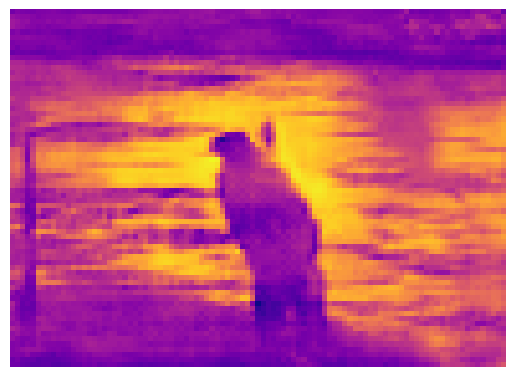

In [ ]:
# use pre-trained generator to create an image
generator.eval()
with torch.no_grad():
    generated_image = (generator(raptor_noise).cpu())

plt.imshow(generated_image[0][0], cmap='plasma')
plt.axis('off')